In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms

In [3]:
MRI_PATH = "/content/drive/MyDrive/DL/Training"
MRI_TEST_PATH = "/content/drive/MyDrive/DL/Testing"

SEG_PATH = "/content/drive/MyDrive/DL-segmentation/Training"
SEG_TEST_PATH = "/content/drive/MyDrive/DL-segmentation/Testing"

In [4]:
class BrainDataset(Dataset):
    def __init__(self, img_root, mask_root, augment=False):
        self.imgs, self.masks = [], []
        self.augment = augment

        mapping = {
            "glioma": "glioma_tumor",
            "meningioma": "meningioma_tumor",
            "pituitary": "pituitary_tumor",
            "notumor": "no_tumor"
        }

        for cls in mapping:
            img_dir = os.path.join(img_root, cls)
            mask_dir = os.path.join(mask_root, mapping[cls])

            if not os.path.exists(img_dir) or not os.path.exists(mask_dir):
                continue

            imgs = sorted(os.listdir(img_dir))
            masks = sorted(os.listdir(mask_dir))

            for i in range(min(len(imgs), len(masks))):
                self.imgs.append(os.path.join(img_dir, imgs[i]))
                self.masks.append(os.path.join(mask_dir, masks[i]))

        self.base_transform = transforms.Compose([
            transforms.Resize((128,128)),
            transforms.ToTensor()
        ])

        self.aug_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10)
        ])

    def __len__(self):
        return len(self.imgs)

    def __getitem__(self, i):
        img = Image.open(self.imgs[i]).convert("L")
        mask = Image.open(self.masks[i]).convert("L")

        # Apply SAME augmentation to both image & mask
        if self.augment:
            seed = np.random.randint(2147483647)

            torch.manual_seed(seed)
            img = self.aug_transform(img)

            torch.manual_seed(seed)
            mask = self.aug_transform(mask)

        img = self.base_transform(img)
        mask = self.base_transform(mask)

        return img, mask

In [5]:
class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(nn.Conv2d(F_g, F_int, 1), nn.BatchNorm2d(F_int))
        self.W_x = nn.Sequential(nn.Conv2d(F_l, F_int, 1), nn.BatchNorm2d(F_int))

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, 1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU()

    def forward(self, g, x):
        psi = self.relu(self.W_g(g) + self.W_x(x))
        psi = self.psi(psi)
        return x * psi

In [6]:
class AttUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = nn.Conv2d(1,64,3,padding=1)
        self.enc2 = nn.Conv2d(64,128,3,padding=1)

        self.pool = nn.MaxPool2d(2)
        self.up = nn.ConvTranspose2d(128,64,2,2)

        self.att = AttentionGate(64,64,32)
        self.out = nn.Conv2d(64,1,1)

    def forward(self,x):
        e1 = torch.relu(self.enc1(x))
        e2 = torch.relu(self.enc2(self.pool(e1)))

        d1 = self.up(e2)
        e1_att = self.att(d1, e1)

        return torch.sigmoid(self.out(e1_att))

In [7]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc = nn.Sequential(
            nn.Conv2d(1,16,3,2,1),
            nn.ReLU(),
            nn.Conv2d(16,32,3,2,1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(32*32*32,128)
        self.fc_logvar = nn.Linear(32*32*32,128)

        self.fc_dec = nn.Linear(128,32*32*32)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(32,16,3,2,1,1),
            nn.ReLU(),
            nn.ConvTranspose2d(16,1,3,2,1,1),
            nn.Sigmoid()
        )

    def reparam(self, mu, logvar):
        std = torch.exp(0.5*logvar)
        return mu + std*torch.randn_like(std)

    def forward(self,x):
        e = self.enc(x).view(x.size(0), -1)
        mu, logvar = self.fc_mu(e), self.fc_logvar(e)
        z = self.reparam(mu, logvar)
        d = self.fc_dec(z).view(-1,32,32,32)
        return self.dec(d), mu, logvar

In [8]:
class VAE_AttUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.vae = VAE()
        self.unet = AttUNet()

    def forward(self,x):
        recon, mu, logvar = self.vae(x)
        seg = self.unet(recon)
        return recon, seg, mu, logvar

In [14]:
def dice_coeff(pred, target):
    smooth = 1e-8
    intersection = (pred * target).sum()
    return (2. * intersection + smooth) / (pred.sum() + target.sum() + smooth)

def dice_loss(pred, target):
    return 1 - dice_coeff(pred, target)

In [10]:
full_dataset = BrainDataset(MRI_PATH, SEG_PATH, augment=False)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_indices, val_indices = torch.utils.data.random_split(
    range(len(full_dataset)), [train_size, val_size]
)

# Create separate datasets
train_ds = BrainDataset(MRI_PATH, SEG_PATH, augment=True)
val_ds = BrainDataset(MRI_PATH, SEG_PATH, augment=False)

# Subset using same indices
train_ds = torch.utils.data.Subset(train_ds, train_indices.indices)
val_ds = torch.utils.data.Subset(val_ds, val_indices.indices)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=8)

In [11]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.best = 1e9
        self.patience = patience
        self.counter = 0

    def step(self, loss):
        if loss < self.best:
            self.best = loss
            self.counter = 0
        else:
            self.counter += 1
        return self.counter >= self.patience

In [16]:
def train_model(model, epochs=10):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    opt = optim.Adam(model.parameters(), lr=1e-3)
    es = EarlyStopping()

    train_loss_hist, val_loss_hist, dice_hist = [], [], []

    for ep in range(epochs):
        model.train()
        tl = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()

            # -------- FORWARD --------
            if isinstance(model, VAE_AttUNet):
                recon, seg, mu, logvar = model(x)

                # VAE + Dice loss
                recon_loss = nn.functional.mse_loss(recon, x)
                kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                d_loss = dice_loss(seg, y)

                loss = recon_loss + kl + d_loss
                d = dice_coeff(seg, y)

            else:  # Baseline Attention U-Net
                seg = model(x)

                loss = dice_loss(seg, y)
                d = dice_coeff(seg, y)

            # -------- BACKWARD --------
            loss.backward()
            opt.step()

            tl += loss.item()

        # -------- VALIDATION --------
        model.eval()
        vl, vd = 0, 0

        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)

                if isinstance(model, VAE_AttUNet):
                    recon, seg, mu, logvar = model(x)

                    recon_loss = nn.functional.mse_loss(recon, x)
                    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                    d_loss = dice_loss(seg, y)

                    loss = recon_loss + kl + d_loss
                    d = dice_coeff(seg, y)

                else:
                    seg = model(x)

                    loss = dice_loss(seg, y)
                    d = dice_coeff(seg, y)

                vl += loss.item()
                vd += d.item()

        # -------- AVERAGES --------
        tl /= len(train_loader)
        vl /= len(val_loader)
        vd /= len(val_loader)

        train_loss_hist.append(tl)
        val_loss_hist.append(vl)
        dice_hist.append(vd)

        print(f"Epoch {ep+1} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Dice: {vd:.4f}")

        # -------- EARLY STOPPING --------
        if es.step(vl):
            print("Early stopping triggered")
            break

    return train_loss_hist, val_loss_hist, dice_hist

In [17]:
print("Training Baseline")
baseline = AttUNet()
b_tl, b_vl, b_d = train_model(baseline)

print("Training Proposed")
proposed = VAE_AttUNet()
p_tl, p_vl, p_d = train_model(proposed)

Training Baseline
Epoch 1 | Train Loss: 0.6991 | Val Loss: 0.6790 | Dice: 0.3210
Epoch 2 | Train Loss: 0.6510 | Val Loss: 0.6284 | Dice: 0.3716
Epoch 3 | Train Loss: 0.6207 | Val Loss: 0.6238 | Dice: 0.3762
Epoch 4 | Train Loss: 0.6181 | Val Loss: 0.6219 | Dice: 0.3781
Epoch 5 | Train Loss: 0.6172 | Val Loss: 0.6216 | Dice: 0.3784
Epoch 6 | Train Loss: 0.6169 | Val Loss: 0.6222 | Dice: 0.3778
Epoch 7 | Train Loss: 0.6164 | Val Loss: 0.6216 | Dice: 0.3784
Epoch 8 | Train Loss: 0.6166 | Val Loss: 0.6220 | Dice: 0.3780
Early stopping triggered
Training Proposed
Epoch 1 | Train Loss: 0.7693 | Val Loss: 0.7078 | Dice: 0.3197
Epoch 2 | Train Loss: 0.6783 | Val Loss: 0.6401 | Dice: 0.3846
Epoch 3 | Train Loss: 0.6292 | Val Loss: 0.6297 | Dice: 0.3926
Epoch 4 | Train Loss: 0.6249 | Val Loss: 0.6265 | Dice: 0.3954
Epoch 5 | Train Loss: 0.6228 | Val Loss: 0.6258 | Dice: 0.3955
Epoch 6 | Train Loss: 0.6229 | Val Loss: 0.6264 | Dice: 0.3949
Epoch 7 | Train Loss: 0.6221 | Val Loss: 0.6262 | Dice: 0

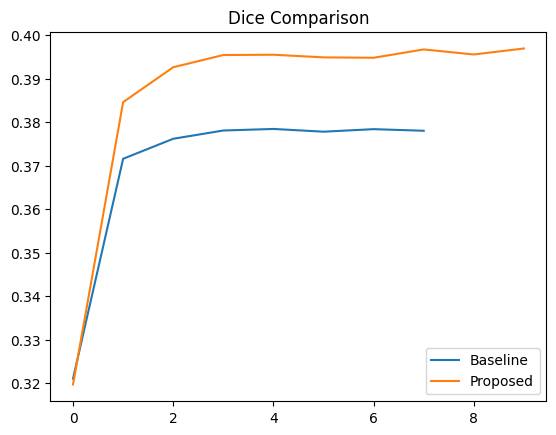

In [18]:
plt.figure()
plt.plot(b_d, label="Baseline")
plt.plot(p_d, label="Proposed")
plt.legend()
plt.title("Dice Comparison")
plt.show()

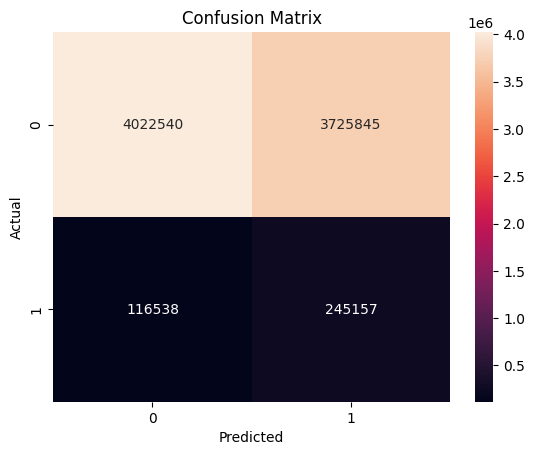

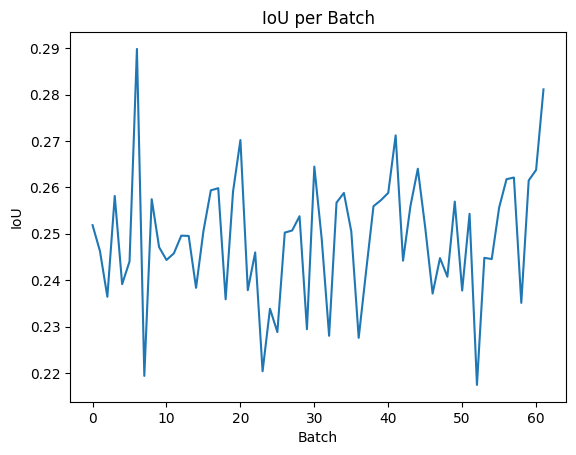

Precision: 0.06173681101142734
Recall: 0.677800356654087
F1 Score: 0.11316600260761368


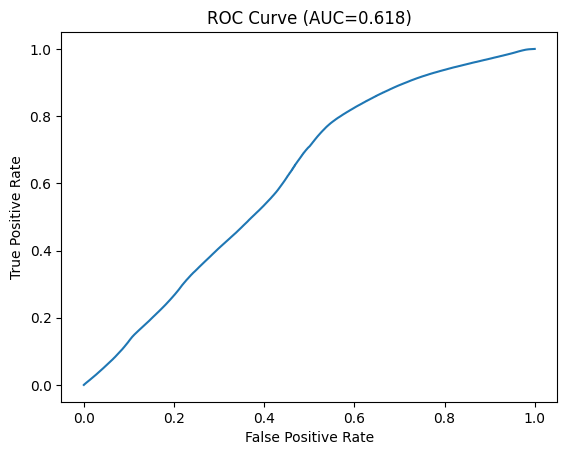


--- Final Results ---
Baseline Dice: 0.378
Proposed Dice: 0.397
Mean IoU: 0.249
Precision: 0.062
Recall: 0.678
F1 Score: 0.113
AUC: 0.618


In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc
import seaborn as sns

def iou_score(pred, target):
    pred = (pred > 0.5).float()
    inter = (pred * target).sum()
    union = pred.sum() + target.sum() - inter
    return (inter / (union + 1e-8)).item()

proposed.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

all_preds, all_targets, all_probs = [], [], []
ious = []

with torch.no_grad():
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)

        _, seg, _, _ = proposed(x)

        # ✅ probabilities (for ROC)
        probs = seg.detach().cpu().numpy().flatten()

        # ✅ binary predictions
        preds = (seg > 0.5).float().detach().cpu().numpy().astype(int).flatten()

        # ✅ binary targets
        targets = (y > 0.5).float().detach().cpu().numpy().astype(int).flatten()

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_targets.extend(targets)

        ious.append(iou_score(seg, y))

# Convert to numpy
all_preds = np.array(all_preds).astype(int)
all_targets = np.array(all_targets).astype(int)
all_probs = np.array(all_probs)

# ✅ CONFUSION MATRIX
cm = confusion_matrix(all_targets, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ✅ IoU GRAPH
plt.figure()
plt.plot(ious)
plt.title("IoU per Batch")
plt.xlabel("Batch")
plt.ylabel("IoU")
plt.show()

# ✅ PRECISION / RECALL / F1
precision = precision_score(all_targets, all_preds, zero_division=0)
recall = recall_score(all_targets, all_preds, zero_division=0)
f1 = f1_score(all_targets, all_preds, zero_division=0)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# ✅ ROC CURVE
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.title(f"ROC Curve (AUC={roc_auc:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# ✅ FINAL RESULTS TABLE
print("\n--- Final Results ---")
print(f"Baseline Dice: {b_d[-1]:.3f}")
print(f"Proposed Dice: {p_d[-1]:.3f}")
print(f"Mean IoU: {np.mean(ious):.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"AUC: {roc_auc:.3f}")